# Business Understanding

## FedEx Fuel Consumption and Price Forecasting

### Business Understanding

#### Business Problem

Fuel is a major operating cost for transportation and logistics companies such as FedEx. Changes in fuel consumption and fuel prices can therefore affect operational costs and overall business performance.

The objective of this project is to use historical fuel and related data to predict future fuel requirements and fuel prices.

#### Main Questions

1. Can we predict FedEx's fuel consumption for the following week using historical fuel consumption data?
2. Can we predict the following week's fuel price using historical fuel prices and crude oil prices?
3. How strongly is FedEx fuel cost related to crude oil and other fuel prices?
4. Which historical and external variables are most useful for predicting future fuel consumption and price?

#### Project Objectives

The project will:

- Analyze historical fuel consumption and fuel price trends.
- Investigate relationships between crude oil, fuel prices and FedEx fuel consumption.
- Create time-based and lagged features from historical data.
- Establish simple forecasting baselines.
- Train and compare machine learning/time-series models.
- Evaluate the models using appropriate forecasting metrics.
- Forecast the next week's fuel consumption and fuel price.
- Interpret the factors contributing to the forecasts.

#### Target Variables

The primary targets will be:

- Future fuel consumption
- Future fuel price

The exact target columns will be determined after inspecting the dataset.

#### Success Criteria

A successful model should perform better than a simple baseline forecast and provide useful predictions without using information that would not have been available at the time of prediction.

## 2. Importing Libraries

The following libraries will be used for data manipulation, visualization, statistical analysis and machine learning.

We will initially import only the libraries needed for data understanding and exploration. Additional libraries will be added later when required.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully.


## 3. Loading the Datasets

This project uses multiple datasets from different sources. Each dataset provides information that will contribute to understanding and forecasting fuel consumption and fuel prices.

The main datasets are:

1. **WTI Crude Oil Prices**
   - Provides daily West Texas Intermediate (WTI) crude oil prices.
   - Used as a macroeconomic indicator of movements in the oil market.

2. **FedEx International Fuel Surcharge**
   - Provides historical FedEx international fuel surcharge rates and the corresponding jet fuel price ranges.
   - Used to investigate the relationship between fuel prices and FedEx pricing.

3. **EIA State Fuel Prices**
   - Provides weekly retail gasoline and diesel prices by U.S. state.
   - Used to represent ground transportation fuel costs.

4. **California Household Travel Survey**
   - Provides household, vehicle and travel information.
   - May be used as a proxy for vehicle usage, travel distance and fuel-consumption patterns.

At this stage, the datasets will be loaded independently. No cleaning, transformation or merging will be performed until the structure and quality of each dataset have been understood.

In [5]:
DCOILWTICO_df = "../data/raw/DCOILWTICO.csv"
international_fuel_surcharge_df = "../data/raw/international-fuel-surcharge.csv"
state_prices_df = "../data/raw/state-prices.csv"

wti_df = pd.read_csv(DCOILWTICO_df)
fuel_surcharge_df = pd.read_csv(international_fuel_surcharge_df)
state_prices_df = pd.read_csv(state_prices_df)

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [6]:
print("WTI Crude Oil Prices:")
display(wti_df.head())

print("\nFedEx International Fuel Surcharge:")
display(fuel_surcharge_df.head())

print("\nEIA State Fuel Prices:")
display(state_prices_df.head())

WTI Crude Oil Prices:


,observation_date,DCOILWTICO
0,2021-09-09,68.26
1,2021-09-10,69.82
2,2021-09-13,70.54
3,2021-09-14,70.53
4,2021-09-15,72.59



FedEx International Fuel Surcharge:


,Week,Week Price,Surcharge
0,"14 September, 2026 - 20 September, 2026",$4.08,49.00%
1,"07 September, 2026 - 13 September, 2026",$3.72,46.00%
2,"31 August, 2026 - 06 September, 2026",$3.92,47.75%
3,"24 August, 2026 - 30 August, 2026",$3.77,46.50%
4,"17 August, 2026 - 23 August, 2026",$3.43,43.50%



EIA State Fuel Prices:


,state,abbr,slug,padd,regular_price,regular_basis,regular_eia_area,regular_series,diesel_price,diesel_basis,diesel_eia_area,diesel_series,survey_week
0,Connecticut,CT,connecticut,1,4.096,region,New England (PADD 1A),EMM_EPMR_PTE_R1X_DPG,5.736,region,New England (PADD 1A),EMD_EPD2D_PTE_R1X_DPG,2026-08-31
1,Maine,ME,maine,1,4.096,region,New England (PADD 1A),EMM_EPMR_PTE_R1X_DPG,5.736,region,New England (PADD 1A),EMD_EPD2D_PTE_R1X_DPG,2026-08-31
2,Massachusetts,MA,massachusetts,1,4.068,state,Massachusetts,EMM_EPMR_PTE_SMA_DPG,5.736,region,New England (PADD 1A),EMD_EPD2D_PTE_R1X_DPG,2026-08-31
3,New Hampshire,NH,new-hampshire,1,4.096,region,New England (PADD 1A),EMM_EPMR_PTE_R1X_DPG,5.736,region,New England (PADD 1A),EMD_EPD2D_PTE_R1X_DPG,2026-08-31
4,Rhode Island,RI,rhode-island,1,4.096,region,New England (PADD 1A),EMM_EPMR_PTE_R1X_DPG,5.736,region,New England (PADD 1A),EMD_EPD2D_PTE_R1X_DPG,2026-08-31


### 3.1 Initial Dataset Structure

The datasets originate from different sources and therefore may have different structures, column names, date formats and levels of aggregation.

We will inspect the shape and columns of each dataset before proceeding with data preparation.

This allows us to determine:

- The number of observations and variables.
- The variables available for analysis.
- The time period covered.
- The level of aggregation.
- Which variables may be useful for forecasting.

In [8]:
print("WTI dataset shape:", wti_df.shape)
print("WTI columns:")
print(wti_df.columns.tolist())

print("\nFedEx fuel surcharge dataset shape:", fuel_surcharge_df.shape)
print("FedEx fuel surcharge columns:")
print(fuel_surcharge_df.columns.tolist())

print("\nState fuel prices dataset shape:", state_prices_df.shape)
print("State fuel prices columns:")
print(state_prices_df.columns.tolist())

WTI dataset shape: (1305, 2)
WTI columns:
['observation_date', 'DCOILWTICO']

FedEx fuel surcharge dataset shape: (13, 3)
FedEx fuel surcharge columns:
['Week', 'Week Price', 'Surcharge']

State fuel prices dataset shape: (51, 13)
State fuel prices columns:
['state', 'abbr', 'slug', 'padd', 'regular_price', 'regular_basis', 'regular_eia_area', 'regular_series', 'diesel_price', 'diesel_basis', 'diesel_eia_area', 'diesel_series', 'survey_week']


### 3.2 Dataset Information

We will examine the data types and non-null counts for each dataset.

This is an initial data-understanding step. We will not modify the data yet.

In [9]:
print("WTI Dataset Information")
wti_df.info()

print("\n" + "="*60 + "\n")

print("FedEx Fuel Surcharge Dataset Information")
fuel_surcharge_df.info()

print("\n" + "="*60 + "\n")

print("State Fuel Prices Dataset Information")
state_prices_df.info()

WTI Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 1305 entries, 0 to 1304
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  1305 non-null   str    
 1   DCOILWTICO        1248 non-null   float64
dtypes: float64(1), str(1)
memory usage: 20.5 KB


FedEx Fuel Surcharge Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Week        13 non-null     str  
 1   Week Price  13 non-null     str  
 2   Surcharge   13 non-null     str  
dtypes: str(3)
memory usage: 444.0 bytes


State Fuel Prices Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   state             51 non-null     str    
 

### 3.3 Previewing the Datasets

The first few observations provide an initial view of how the variables are represented.

We will inspect both the beginning and end of each dataset to understand the chronological coverage and identify any obvious structural differences.

In [10]:
print("WTI - First 5 rows")
display(wti_df.head())

print("WTI - Last 5 rows")
display(wti_df.tail())

print("FedEx Fuel Surcharge - First 5 rows")
display(fuel_surcharge_df.head())

print("FedEx Fuel Surcharge - Last 5 rows")
display(fuel_surcharge_df.tail())

print("State Prices - First 5 rows")
display(state_prices_df.head())

print("State Prices - Last 5 rows")
display(state_prices_df.tail())

WTI - First 5 rows


,observation_date,DCOILWTICO
0,2021-09-09,68.26
1,2021-09-10,69.82
2,2021-09-13,70.54
3,2021-09-14,70.53
4,2021-09-15,72.59


WTI - Last 5 rows


,observation_date,DCOILWTICO
1300,2026-09-03,92.55
1301,2026-09-04,92.69
1302,2026-09-07,NaN
1303,2026-09-08,94.21
1304,2026-09-09,97.26


FedEx Fuel Surcharge - First 5 rows


...

,Week,Week Price,Surcharge
8,"20 July, 2026 - 26 July, 2026",$2.97,39.75%
9,"13 July, 2026 - 19 July, 2026",$2.82,38.50%
10,"06 July, 2026 - 12 July, 2026",$2.79,38.25%
11,"29 June, 2026 - 05 July, 2026",$2.84,38.50%
12,"22 June, 2026 - 28 June, 2026",$3.19,41.50%


State Prices - First 5 rows


,state,abbr,slug,padd,regular_price,regular_basis,regular_eia_area,regular_series,diesel_price,diesel_basis,diesel_eia_area,diesel_series,survey_week
0,Connecticut,CT,connecticut,1,4.096,region,New England (PADD 1A),EMM_EPMR_PTE_R1X_DPG,5.736,region,New England (PADD 1A),EMD_EPD2D_PTE_R1X_DPG,2026-08-31
1,Maine,ME,maine,1,4.096,region,New England (PADD 1A),EMM_EPMR_PTE_R1X_DPG,5.736,region,New England (PADD 1A),EMD_EPD2D_PTE_R1X_DPG,2026-08-31
2,Massachusetts,MA,massachusetts,1,4.068,state,Massachusetts,EMM_EPMR_PTE_SMA_DPG,5.736,region,New England (PADD 1A),EMD_EPD2D_PTE_R1X_DPG,2026-08-31
3,New Hampshire,NH,new-hampshire,1,4.096,region,New England (PADD 1A),EMM_EPMR_PTE_R1X_DPG,5.736,region,New England (PADD 1A),EMD_EPD2D_PTE_R1X_DPG,2026-08-31
4,Rhode Island,RI,rhode-island,1,4.096,region,New England (PADD 1A),EMM_EPMR_PTE_R1X_DPG,5.736,region,New England (PADD 1A),EMD_EPD2D_PTE_R1X_DPG,2026-08-31


State Prices - Last 5 rows


,state,abbr,slug,padd,regular_price,regular_basis,regular_eia_area,regular_series,diesel_price,diesel_basis,diesel_eia_area,diesel_series,survey_week
46,California,CA,california,5,5.520,state,California,EMM_EPMR_PTE_SCA_DPG,7.218,state,California,EMD_EPD2D_PTE_SCA_DPG,2026-08-31
47,Hawaii,HI,hawaii,5,4.823,region,West Coast less California,EMM_EPMR_PTE_R5XCA_DPG,5.872,region,West Coast less California,EMD_EPD2D_PTE_R5XCA_DPG,2026-08-31
48,Nevada,NV,nevada,5,4.823,region,West Coast less California,EMM_EPMR_PTE_R5XCA_DPG,5.872,region,West Coast less California,EMD_EPD2D_PTE_R5XCA_DPG,2026-08-31
49,Oregon,OR,oregon,5,4.823,region,West Coast less California,EMM_EPMR_PTE_R5XCA_DPG,5.872,region,West Coast less California,EMD_EPD2D_PTE_R5XCA_DPG,2026-08-31
50,Washington,WA,washington,5,5.259,state,Washington,EMM_EPMR_PTE_SWA_DPG,5.872,region,West Coast less California,EMD_EPD2D_PTE_R5XCA_DPG,2026-08-31


## 4 Data Understanding

### 4.1 WTI Crude Oil Dataset

The WTI dataset contains daily crude oil spot prices from September 2021 onward.

It contains two variables:

- `observation_date`: Date of the observation.
- `DCOILWTICO`: WTI crude oil spot price in U.S. dollars per barrel.

The dataset contains 1,305 observations. There are 1,248 non-null price observations, meaning that 57 observations contain missing WTI prices.

Because this is a time-series dataset, the date variable will be particularly important for ordering observations and creating future forecasting features.

In [11]:
wti_df.head()

,observation_date,DCOILWTICO
0,2021-09-09,68.26
1,2021-09-10,69.82
2,2021-09-13,70.54
3,2021-09-14,70.53
4,2021-09-15,72.59


In [12]:
wti_df["DCOILWTICO"].describe()

count    1248.000000
mean       79.265673
std        13.316883
min        55.440000
25%        70.090000
50%        77.670000
75%        86.000000
max       123.640000
Name: DCOILWTICO, dtype: float64

### 4.2 WTI Date Range

We will determine the period covered by the WTI dataset.

Understanding the time span is important because forecasting models require sufficient historical observations to learn trends, patterns and changes over time.

In [13]:
wti_df["observation_date"] = pd.to_datetime(wti_df["observation_date"])

print("Start date:", wti_df["observation_date"].min())
print("End date:", wti_df["observation_date"].max())

Start date: 2021-09-09 00:00:00
End date: 2026-09-09 00:00:00


### 4.3 Missing Values in WTI Prices

The WTI dataset contains missing price observations.

Before deciding how to handle these missing values, we will investigate when they occur and whether they correspond to non-trading days or other gaps in the time series.

Missing observations should not automatically be removed or filled without first understanding their cause.

In [14]:
wti_df[wti_df["DCOILWTICO"].isna()].head(20)

,observation_date,DCOILWTICO
55,2021-11-25,NaN
56,2021-11-26,NaN
76,2021-12-24,NaN
92,2022-01-17,NaN
117,2022-02-21,NaN
156,2022-04-15,NaN
187,2022-05-30,NaN
202,2022-06-20,NaN
212,2022-07-04,NaN
257,2022-09-05,NaN


In [15]:
print("Total missing WTI prices:", wti_df["DCOILWTICO"].isna().sum())

Total missing WTI prices: 57


### 4.4 WTI Observation Frequency

The WTI dataset is recorded at a daily frequency.

Our final forecasting problem is focused on weekly fuel consumption and fuel prices. Therefore, WTI will eventually need to be aligned with the weekly datasets.

Before performing this transformation, we will examine the distribution of observations across dates and identify gaps caused by weekends and market holidays.

In [16]:
wti_df["observation_date"].diff().value_counts().head(10)

observation_date
1 days    1043
3 days     261
Name: count, dtype: int64

### 4.5 WTI Crude Oil Price Trend

A time-series plot will be used to visualize how WTI crude oil prices have changed over the period covered by the dataset.

This will help us identify:

- Overall trends
- Periods of high and low prices
- Sudden price movements
- Potential outliers
- Changes in volatility

Understanding these patterns will help determine which transformations and forecasting features may be useful later.

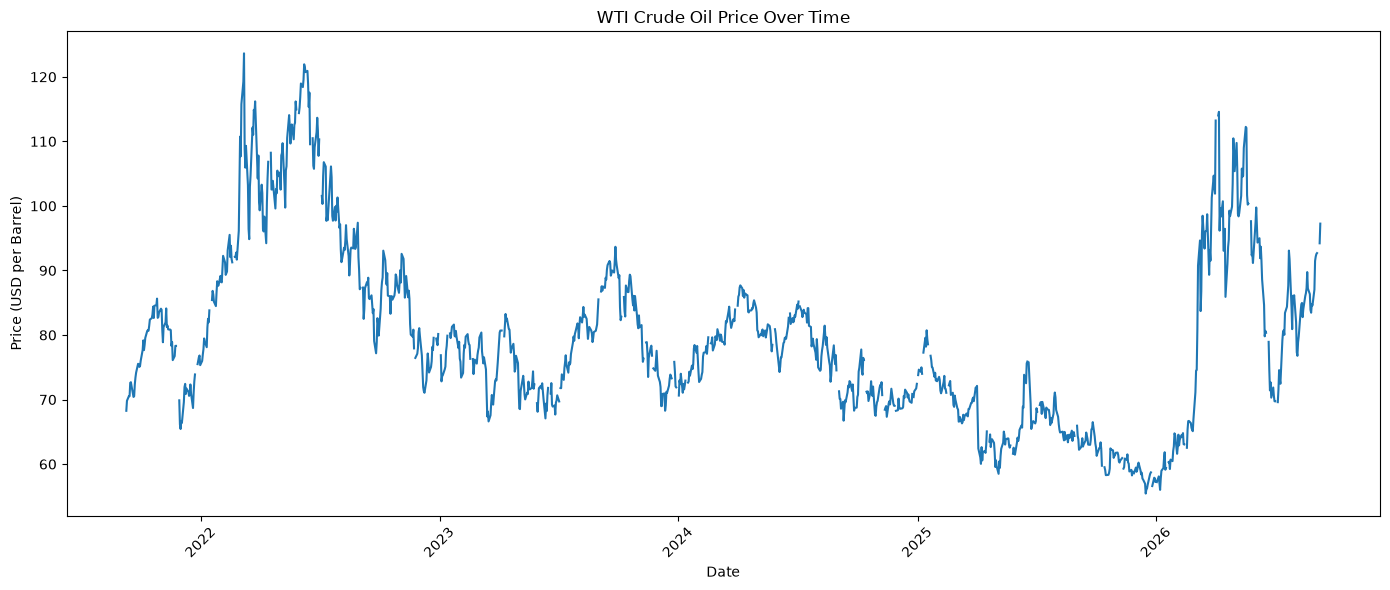

In [24]:
plt.figure(figsize=(14, 6))

plt.plot(
    wti_df["observation_date"],
    wti_df["DCOILWTICO"]
)

plt.title("WTI Crude Oil Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD per Barrel)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### 4.6 WTI Price Distribution

A distribution plot will help us understand how frequently different WTI price levels occur.

This will allow us to identify the typical price range and investigate whether extreme price observations exist.

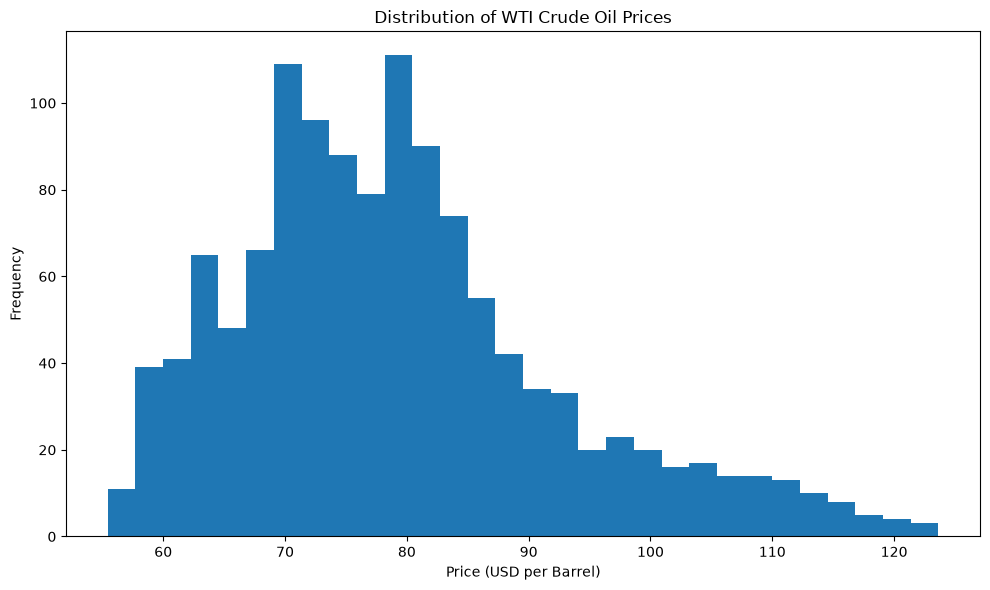

In [26]:
plt.figure(figsize=(10, 6))

plt.hist(
    wti_df["DCOILWTICO"].dropna(),
    bins=30
)

plt.title("Distribution of WTI Crude Oil Prices")
plt.xlabel("Price (USD per Barrel)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### 4.7 Investigating Extreme WTI Prices

The descriptive statistics indicate substantial variation in WTI prices.

Instead of automatically treating extreme observations as errors or outliers, we will identify their dates and investigate whether they represent genuine market movements.

In a financial or commodity time series, extreme observations can contain important information and should not automatically be removed.

In [27]:
print("Lowest WTI prices:")
display(
    wti_df.nsmallest(10, "DCOILWTICO")
)

print("\nHighest WTI prices:")
display(
    wti_df.nlargest(10, "DCOILWTICO")
)

Lowest WTI prices:


,observation_date,DCOILWTICO
1113,2025-12-16,55.44
1129,2026-01-07,56.01
1114,2025-12-17,56.07
1115,2025-12-18,56.22
1121,2025-12-26,56.60
1116,2025-12-19,56.80
1112,2025-12-15,56.97
1128,2026-01-06,56.97
1126,2026-01-02,57.21
1124,2025-12-31,57.26



Highest WTI prices:


,observation_date,DCOILWTICO
128,2022-03-08,123.64
194,2022-06-08,121.94
195,2022-06-09,121.52
197,2022-06-13,120.92
196,2022-06-10,120.73
193,2022-06-07,119.55
127,2022-03-07,119.26
191,2022-06-03,118.97
198,2022-06-14,118.92
192,2022-06-06,118.41


## 5. FedEx International Fuel Surcharge Dataset

The FedEx International Fuel Surcharge dataset contains weekly observations linking a published U.S. Gulf Coast jet fuel price with the corresponding FedEx international fuel surcharge.

The dataset currently contains 13 weekly observations.

Because 13 observations are insufficient for training a reliable time-series forecasting model, this dataset will not be treated as the primary forecasting dataset.

Instead, it will initially be used to investigate the relationship between jet fuel prices and FedEx fuel surcharges.

If a longer historical FedEx surcharge dataset can be obtained, it may later be incorporated into the analysis.

In [19]:
display(fuel_surcharge_df)

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.

,Week,Week Price,Surcharge
0,"14 September, 2026 - 20 September, 2026",$4.08,49.00%
1,"07 September, 2026 - 13 September, 2026",$3.72,46.00%
2,"31 August, 2026 - 06 September, 2026",$3.92,47.75%
3,"24 August, 2026 - 30 August, 2026",$3.77,46.50%
4,"17 August, 2026 - 23 August, 2026",$3.43,43.50%
5,"10 August, 2026 - 16 August, 2026",$3.74,46.00%
6,"03 August, 2026 - 09 August, 2026",$3.68,45.50%
7,"27 July, 2026 - 02 August, 2026",$3.50,44.00%
8,"20 July, 2026 - 26 July, 2026",$2.97,39.75%
9,"13 July, 2026 - 19 July, 2026",$2.82,38.50%


## 6. EIA State Fuel Prices

The EIA dataset contains gasoline and diesel prices for 50 U.S. states and Washington D.C.

The dataset currently contains 51 observations corresponding to a single survey week.

Therefore, it cannot currently be used to model weekly fuel-price trends.

However, it provides useful information about the geographic variation in gasoline and diesel prices.

For the forecasting stage, a longer historical weekly EIA dataset will be required.

In [20]:
state_prices_df.describe()

,padd,regular_price,diesel_price
count,51.000000,51.000000,51.000000
mean,2.372549,4.069000,5.628431
std,1.413659,0.424192,0.298986
min,1.000000,3.577000,5.276000
25%,1.000000,3.836000,5.555000
50%,2.000000,3.847000,5.571000
75%,3.000000,4.121500,5.787000
max,5.000000,5.520000,7.218000


### 6.1 State Diesel Price Distribution

Diesel is an important fuel for ground transportation.

We will examine the distribution of diesel prices across the states to understand the geographic variation in fuel costs.

In [21]:
state_prices_df["diesel_price"].describe()

count    51.000000
mean      5.628431
std       0.298986
min       5.276000
25%       5.555000
50%       5.571000
75%       5.787000
max       7.218000
Name: diesel_price, dtype: float64

In [22]:
state_prices_df[
    ["state", "abbr", "diesel_price"]
].sort_values("diesel_price", ascending=False).head(10)

,state,abbr,diesel_price
46,California,CA,7.218
50,Washington,WA,5.872
45,Arizona,AZ,5.872
49,Oregon,OR,5.872
44,Alaska,AK,5.872
48,Nevada,NV,5.872
47,Hawaii,HI,5.872
10,New York,NY,5.838
8,Maryland,MD,5.838
9,New Jersey,NJ,5.838


In [23]:
state_prices_df[
    ["state", "abbr", "diesel_price"]
].sort_values("diesel_price").head(10)

,state,abbr,diesel_price
12,Florida,FL,5.276
13,Georgia,GA,5.276
14,North Carolina,NC,5.276
15,South Carolina,SC,5.276
17,West Virginia,WV,5.276
16,Virginia,VA,5.276
34,Arkansas,AR,5.360
33,Alabama,AL,5.360
36,Mississippi,MS,5.360
35,Louisiana,LA,5.360
